# **Spotify Data Analysis (EDA Workflow)**
## **Course:** 4379G
### **Author:** Sebastian Zeidler
### Do most popular songs share certain audio features? Are songs with certain audio features more likely to be popular? Are there sub genres/hidden genres based on overlapping features that aren’t currently recognized by Spotify?

In [ ]:
# ══════════════════════════════════════════════════════════════
#  IMPORTS 
# ══════════════════════════════════════════════════════════════

# ── Core Libraries ──
import numpy as np
import pandas as pd
from scipy import stats

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── PCA Analysis and Clustering ──
import sklearn

ModuleNotFoundError: No module named 'seaborn'

## Step 1: Load Dataset 
### Read data into memory; first look

In [2]:
# ══════════════════════════════════════════════════════════════
#  LOAD DATASET
# ══════════════════════════════════════════════════════════════

data = pd.read_csv("./data/dataset.csv")
print(f"Successfully loaded the dataset!")

Successfully loaded the dataset!


In [ ]:
# ══════════════════════════════════════════════════════════════
#  FIRST LOOK
# ══════════════════════════════════════════════════════════════

# ── First 5 Rows ──
data.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# ── Last 5 Rows ──
data.tail(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [ ]:
# ── Random Sample ──
data.sample(5, random_state=42)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113186,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,...,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
42819,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,...,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
59311,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,...,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
91368,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,...,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
61000,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,...,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


## Step 2: Inspect
### Shape, column types, inventory

In [ ]:
# ══════════════════════════════════════════════════════════════
#  UNDERSTAND THE SHAPE
# ══════════════════════════════════════════════════════════════

# ── Dimensions ──
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
print()

# ── Column names, types, and null counts ──
print(data.info())

Rows: 114,000
Columns: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float6

### ── What do we notice? ──
- `track_id`, `artists`, `album_name`, `track_name`, and `track_genre` are objects → string conversion not necessary in this case
- `artists`, `album_name`, `track_name` contain null values → need to investigate further
- `unnamed: 0` is a duplicate index row → need to remove it

In [ ]:
# ── Fix the duplicate index column immediately ──
df = data.copy()
df = df.drop(columns=["Unnamed: 0"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

## Step 3: Clean
### Handle missing values, duplicates

In [ ]:
# ══════════════════════════════════════════════════════════════
#  MISSING VALUE REPORT
# ══════════════════════════════════════════════════════════════

missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

print("Columns with missing values:\n")
print(missing)
print()

print(f"\nTotal cells with NaN: {df.isnull().sum().sum()}")

Columns with missing values:

                  missing_count  missing_pct
track_id                      0          0.0
artists                       1          0.0
album_name                    1          0.0
track_name                    1          0.0
popularity                    0          0.0
duration_ms                   0          0.0
explicit                      0          0.0
danceability                  0          0.0
energy                        0          0.0
key                           0          0.0
loudness                      0          0.0
mode                          0          0.0
speechiness                   0          0.0
acousticness                  0          0.0
instrumentalness              0          0.0
liveness                      0          0.0
valence                       0          0.0
tempo                         0          0.0
time_signature                0          0.0
track_genre                   0          0.0


Total cells with NaN: 3

In [ ]:
# ── Visualize the pattern of missingness ──
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Value Heatmap — Yellow = Missing', fontsize=14)
plt.tight_layout()
plt.show()

![Figure 1](images/missing_heatmap.png)

In [ ]:
# ══════════════════════════════════════════════════════════════
#  HANDLE MISSING VALUES ACCORDINGLY
# ══════════════════════════════════════════════════════════════

# ── Inspect missing values ──
print(df[df[['artists', 'album_name', 'track_name']].isna().any(axis=1)])

# Only one value missing in the entire set indicates Missing Completely At Random (MCAR). Safe to drop.

# ── Drop missing value ──
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

                     track_id artists album_name track_name  popularity  \
55805  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN        NaN           0   

       duration_ms  explicit  danceability  energy  key  loudness  mode  \
55805            0     False         0.501   0.583    7     -9.46     0   

       speechiness  acousticness  instrumentalness  liveness  valence  \
55805       0.0605          0.69           0.00396    0.0747    0.734   

         tempo  time_signature track_genre  
55805  138.391               4       K-Pop  


In [ ]:
# ── Re-run missing report to verify missing values have been handled properly ──
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

print("Columns with missing values:\n")
print(missing)
print()

print(f"\nTotal cells with NaN: {df.isnull().sum().sum()}")

Columns with missing values:

                  missing_count  missing_pct
track_id                      0          0.0
artists                       0          0.0
album_name                    0          0.0
track_name                    0          0.0
popularity                    0          0.0
duration_ms                   0          0.0
explicit                      0          0.0
danceability                  0          0.0
energy                        0          0.0
key                           0          0.0
loudness                      0          0.0
mode                          0          0.0
speechiness                   0          0.0
acousticness                  0          0.0
instrumentalness              0          0.0
liveness                      0          0.0
valence                       0          0.0
tempo                         0          0.0
time_signature                0          0.0
track_genre                   0          0.0


Total cells with NaN: 0

In [ ]:
# ── Check for constant or empty columns ──
for col in df.columns:
    if df[col].nunique(dropna=False) <= 1:
        print(f"⚠️  '{col}' has {df[col].nunique(dropna=False)} unique value(s) — consider dropping")

In [ ]:
# ══════════════════════════════════════════════════════════════
#  DUPLICATE CHECK
# ══════════════════════════════════════════════════════════════

# ── Exact duplicates ──
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# ── Duplicate track IDs/key based duplicates ──
id_dupes = df['track_id'].duplicated().sum()
print(f"Duplicate track IDs: {id_dupes}")

Exact duplicate rows: 450
Duplicate track IDs: 24259


In [ ]:
# ── Remove duplicates and reset index ──
print(f"Shape BEFORE dedup: {df.shape}")

df = df.drop_duplicates(subset=['track_id'], keep='first').reset_index(drop=True)

print(f"Shape AFTER dedup:  {df.shape}")

NameError: name 'df' is not defined

# Step 4: Describe
## Summary statistics

In [ ]:
# ── Quick statistical summary ──
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,89740,89740,2hETkH7cOfqmz3LqZDHZf5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,89740,31437,George Jones,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,89740,46589,The Complete Hank Williams,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,89740,73608,Rockin' Around The Christmas Tree,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,89740.0,NaN,NaN,NaN,33.198808,20.58064,0.0,19.0,33.0,49.0,100.0
duration_ms,89740.0,NaN,NaN,NaN,229144.365578,112945.780336,8586.0,173040.0,213295.5,264293.0,5237295.0
explicit,89740,2,False,82036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,89740.0,NaN,NaN,NaN,0.562166,0.176692,0.0,0.45,0.576,0.692,0.985
energy,89740.0,NaN,NaN,NaN,0.634458,0.256606,0.0,0.457,0.676,0.853,1.0
key,89740.0,NaN,NaN,NaN,5.28353,3.559912,0.0,2.0,5.0,8.0,11.0


In [ ]:
# ── Summary stats for numerical features ──
df.describe().round(2)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00,89741.00
mean,33.20,229141.81,0.56,0.63,5.28,-8.50,0.64,0.09,0.33,0.17,0.22,0.47,122.06,3.90
std,20.58,112947.74,0.18,0.26,3.56,5.22,0.48,0.11,0.34,0.32,0.19,0.26,30.12,0.45
min,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.00,173040.00,0.45,0.46,2.00,-10.32,0.00,0.04,0.02,0.00,0.10,0.25,99.26,4.00
50%,33.00,213293.00,0.58,0.68,5.00,-7.18,1.00,0.05,0.19,0.00,0.13,0.46,122.01,4.00
75%,49.00,264293.00,0.69,0.85,8.00,-5.11,1.00,0.09,0.62,0.10,0.28,0.68,140.08,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


### ── What do we notice? ──
- `popularity`: Mean is 33.2, max is 100. Most songs are not the most popular.
- `duration_ms`: Mean is 229141.81 ms = ~3.8 min. Max is 5237295.00 ms = ~87.29 min. Meaning most songs are only a few minutes, with some songs stretching over an hour in length. Standard Deviation is high. **Should check for potential outliers.**
- `danceability`: (Range of 0.0 - 1.0) Mean is 0.56 with a max of 0.98. Most songs are "halfway" danceable, with no songs being perfectly danceable.
- `energy`: (Range of 0.0 - 1.0) Mean is 0.63 with a max of 1.0. Most songs are over "halfway" energetic, meaning they are fast, loud, and noisy.
- `key`: Mean is 5.28 representing a key of F and max is 11.00 representing a key of B. Most songs are in the F-F Sharp keys.
- `loudness`: Mean is -8.50 and max is 4.53. Most songs have a loudness of -8.50 decibels with a maximum decibel amount of 4.53. Since decibels in this case should have a maximum value of 0 dB, we must **check for outliers.** 
- `mode`: (Range of 0.0 - 1.0) Mean is 0.64 and max is 1.00. Most tracks are in the major scale, as a value of 1.00 represents the major scale.
- `speechiness`: Mean is 0.09 and max is 0.96. This indicates that most tracks are not exclusively speech-like and contain music. 
- `acousticness`: (Range of 0.0 - 1.0) Mean is 0.33 and max is 1.00. Most tracks are not acoustic, as indicated by a low acousticness score.
- `instrumentalness`: Mean is 0.17 and max is 1.00. This means most tracks contain vocal content, with a max of 1.00 indicating that there are fully instrumental tracks.
- `liveness`: Mean is 0.22 and max is 1.00. This indicates that most tracks on Spotify are not live, as a score of 0.8 or greater indicates the track is live.
- `valence`: Mean is 0.47 and max is 1.00. This indicates that most tracks on Spotify are neutral rather than explicitly negative or positive. 
- `tempo`: Mean is 122.06 and max is 243.37. The average beats per minute (BPM) of tracks is 122 bpm. 
- `time_signature`: Mean is 3.90 and max is 5.00. This indicates most tracks have around a 3/4 to 4/4 tempo. The time signature should range from 3 to 7, meaning we **must check this column.**

In [ ]:
# ── Categorical breakdown ──
cat_cols = ['explicit', 'track_genre', 'key', 'time_signature', 'mode']

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col} — {df[col].nunique()} unique values")
    print('='*50)
    print(df[col].value_counts())


explicit — 2 unique values
explicit
False    82036
True      7704
Name: count, dtype: int64

track_genre — 113 unique values
track_genre
Acoustic     1000
Afrobeat      999
Alt-Rock      999
Ambient       999
Cantopop      999
             ... 
Metal         232
Punk          226
House         210
Indie         134
Reggaeton      74
Name: count, Length: 113, dtype: int64


### ── What do we notice? ──
- More False `explicit` counts than True → Most songs are not explicit
- Most prevalent `track_genre` is Acoustic → Need to see shape of data for better analysis
- 4/4 `time signature` is most common
- Most songs are in the Major `mode`

## Step 5: Univariate Analysis
### One variable at a time 

In [ ]:
# ── Distributions of key numerical features ──
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
axes = axes.flatten()

# Popularity
sns.histplot(df['popularity'], bins=40, kde=True, ax=axes[0], color='#f59e0b')
axes[0].set_title('Distribution of Popularity', fontsize=13)
axes[0].set_xlabel("Popularity")
axes[0].axvline(df['popularity'].mean(), color='red', ls='--', label=f"Mean: {df['popularity'].mean():.2f}")
axes[0].axvline(df['popularity'].median(), color='blue', ls='--', label=f"Median: {df['popularity'].median():.2f}")
axes[0].legend()

# Duration (ms)
sns.histplot(df['duration_ms'], bins=40, kde=True, ax=axes[1], color='#f59e0b')
axes[1].set_title('Distribution of Duration', fontsize=13)
axes[1].set_xlabel("Milliseconds (ms)")
axes[1].axvline(df['duration_ms'].mean(), color='red', ls='--', label=f"Mean: {df['duration_ms'].mean():.2f} ms")
axes[1].axvline(df['duration_ms'].median(), color='blue', ls='--', label=f"Median: {df['duration_ms'].median():.2f} ms")
axes[1].legend()

# Loudness (dB)
sns.histplot(df['loudness'], bins=40, kde=True, ax=axes[2], color='#f59e0b')
axes[2].set_title('Distribution of Loudness', fontsize=13)
axes[2].set_xlabel("Decibels (dB)")
axes[2].axvline(df['loudness'].mean(), color='red', ls='--', label=f"Mean: {df['loudness'].mean():.2f} dB")
axes[2].axvline(df['loudness'].median(), color='blue', ls='--', label=f"Median: {df['loudness'].median():.2f} dB")
axes[2].legend()

# Tempo
sns.histplot(df['tempo'], bins=40, kde=True, ax=axes[3], color='#f59e0b')
axes[3].set_title('Distribution of Tempo', fontsize=13)
axes[3].set_xlabel("Beats per Minute (bpm)")
axes[3].axvline(df['tempo'].mean(), color='red', ls='--', label=f"Mean: {df['tempo'].mean():.2f} bpm")
axes[3].axvline(df['tempo'].median(), color='blue', ls='--', label=f"Median: {df['tempo'].median():.2f} bpm")
axes[3].legend()

# Energy
sns.histplot(df['energy'], bins=40, kde=True, ax=axes[4], color='#f59e0b')
axes[4].set_title('Distribution of Energy', fontsize=13)
axes[4].set_xlabel("Energy")
axes[4].axvline(df['energy'].mean(), color='red', ls='--', label=f"Mean: {df['energy'].mean():.2f}")
axes[4].axvline(df['energy'].median(), color='blue', ls='--', label=f"Median: {df['energy'].median():.2f}")
axes[4].legend()

# Danceability
sns.histplot(df['danceability'], bins=40, kde=True, ax=axes[5], color='#f59e0b')
axes[5].set_title('Distribution of Danceability', fontsize=13)
axes[5].set_xlabel("Danceability")
axes[5].axvline(df['danceability'].mean(), color='red', ls='--', label=f"Mean: {df['danceability'].mean():.2f}")
axes[5].axvline(df['danceability'].median(), color='blue', ls='--', label=f"Median: {df['danceability'].median():.2f}")
axes[5].legend()

# Valence
sns.histplot(df['valence'], bins=40, kde=True, ax=axes[6], color='#f59e0b')
axes[6].set_title('Distribution of Valence', fontsize=13)
axes[6].set_xlabel("Valence")
axes[6].axvline(df['valence'].mean(), color='red', ls='--', label=f"Mean: {df['valence'].mean():.2f}")
axes[6].axvline(df['valence'].median(), color='blue', ls='--', label=f"Median: {df['valence'].median():.2f}")
axes[6].legend()

# Speechiness
sns.histplot(df['speechiness'], bins=40, kde=True, ax=axes[7], color='#f59e0b')
axes[7].set_title('Distribution of Speechiness', fontsize=13)
axes[7].set_xlabel("Speechiness")
axes[7].axvline(df['speechiness'].mean(), color='red', ls='--', label=f"Mean: {df['speechiness'].mean():.2f}")
axes[7].axvline(df['speechiness'].median(), color='blue', ls='--', label=f"Median: {df['speechiness'].median():.2f}")
axes[7].legend()

# Acousticness
sns.histplot(df['acousticness'], bins=40, kde=True, ax=axes[8], color='#f59e0b')
axes[8].set_title('Distribution of Acousticness', fontsize=13)
axes[8].set_xlabel("Acousticness")
axes[8].axvline(df['acousticness'].mean(), color='red', ls='--', label=f"Mean: {df['acousticness'].mean():.2f}")
axes[8].axvline(df['acousticness'].median(), color='blue', ls='--', label=f"Median: {df['acousticness'].median():.2f}")
axes[8].legend()

# Instrumentalness
sns.histplot(df['instrumentalness'], bins=40, kde=True, ax=axes[9], color='#f59e0b')
axes[9].set_title('Distribution of Instrumentalness', fontsize=13)
axes[9].set_xlabel("Instrumentalness")
axes[9].axvline(df['instrumentalness'].mean(), color='red', ls='--', label=f"Mean: {df['instrumentalness'].mean():.2f}")
axes[9].axvline(df['instrumentalness'].median(), color='blue', ls='--', label=f"Median: {df['instrumentalness'].median():.2f}")
axes[9].legend()

plt.tight_layout()
plt.show()

![Figure 2](images/numerical_histogram.png)

### ── What do we notice? ──
- `popularity`: Popularity has an uneven distribution, with the largest box at 0.00 popularity. 
- `duration_ms`: Duration is right skewed, meaning most songs have a lower duration. 
- `danceability`: Danceability is nearly symmetric, with a slight left skew, indicating more songs have higher danceability scores.
- `energy`: Left skewed data indicates most songs have a higher energy level.
- `loudness`: Left skewed data indicates most songs are higher decibels. Also shows that decibels are measured with 0 dB as the maximum.
- `speechiness`: Right skewed data indicating most songs have instruments and are not solely vocal speech. 
- `acousticness`: Right skewed data indicating most songs are not fully acoustic. 
- `instrumentalness`: Right skewed data indicating most songs have some for of vocality, with less songs being fully instrumental.
- `valence`: Nearly symmetrical.
- `tempo`: Slight left tail indicating most songs are above 50 bpm. 

In [ ]:
# ── Bar charts for categorical features ──
plots = [
    ("explicit", "Explicit Distribution"),
    ("track_genre", "Track Genre Distribution"),
    ("key", "Key Distribution"),
    ("time_signature", "Time Signature Distribution"),
    ("mode", "Mode Distribution"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 24))
axes = axes.flatten()

for i, (col, title) in enumerate(plots):
    ax = axes[i]

    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette="viridis")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Count")

    # Add count labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=5, fontsize=9)

# Turn off unused subplot
axes[-1].axis("off")

plt.suptitle("Categorical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

![Figure 3](images/bar_charts.png)

### ── What do we notice? ──
- There are more non-`explicit` tracks than `explicit` tracks. Could there be a correlation between certain track_genres, explicitness, and popularity?
- Most common `track_genre`is Acoustic. This is of note because our previous analysis showed most songs do not have a high acousticness score.
- Most common `key` is G (or 7 in Pitch Class Notation) while D#, G#, A#, and F# (3, 8, 10, and 6) are least common. Most common sharp key is C#. 
- Most common `time_signature` is 4/4. Least common is 0/4, which is technically not a valid time signature. Could indicate free time/no time signature. 

## Step 6: Bivariate Analysis
### Two-variable relationships 

In [ ]:
# ── correlation matrix ──
numeric_cols = ['popularity', 'duration_ms', 'loudness', 'tempo', 'energy', 'danceability', 'valence', 'speechiness', 'acousticness', 'instrumentalness']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,10))

sns.heatmap(corr, annot=True, cmap="Spectral", center=0,)

plt.title("Correlation Matrix", fontsize=14)
plt.show()

print("\n Key correlations:")
print(f"  energy ↔ loudness:     {corr.loc['energy','loudness']:.2f}  (strong)")
print(f"  valence ↔ danceability:   {corr.loc['valence','danceability']:.2f}  (moderate)")
print(f"  loudness ↔ tempo:   {corr.loc['loudness','tempo']:.2f}  (low)")

![Figure 4](images/corr_matrix.png)

### ── What do we notice? ──
- No strong correlation between `popularity` and any other column. 
- Strong correlation between `energy` and `loudness.`
- Moderate correlation between `valence` and `danceability.`

In [ ]:
# ── scatter plot ──
plots = [
    ("danceability", "popularity", "Popularity vs Danceability"),
    ("energy", "popularity", "Popularity vs Energy"),
    ("valence", "popularity", "Popularity vs Valence"),
    ("energy", "loudness", "Energy vs Loudness"),
    ("danceability", "valence", "Danceability vs Valence"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (x, y, title) in enumerate(plots):
    ax = axes[i]

    sns.scatterplot(
        data=df, x=x, y=y, 
        alpha=0.2, s=15, color="#f59e0b", ax=ax
    )

    # Add trend line
    clean = df[[x, y]].dropna()
    z = np.polyfit(clean[x], clean[y], 1)
    p = np.poly1d(z)

    x_line = np.linspace(clean[x].min(), clean[x].max(), 100)
    ax.plot(x_line, p(x_line), color="red", linestyle="--", linewidth=2)

    ax.set_title(title, fontsize=12)

# Turn off unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

![Figure 5](images/scatterplot.png)

### ── What do we notice? ──
- `popularity` vs `valence` and `popularity` vs `energy` have straight trend lines, indicating `valence` and `energy` do not predict `popularity` well.
- `popularity` vs `danceability` has a slightly positive sloping trend line, meaning `danceability` predicts `popularity` more strongly than `valence` or `energy.` The trend line is not strong enough to be significant however.
- `energy` vs `loudness` has a positively sloping trend line, meaning higher `energy` is more likely to be associated with `loudness.`
- `danceability` vs `valence` has a strongly positively sloping trend line, meaning `danceability` and `valence` have a significant relationship.

## Step 7: Multivariate Analysis
### 3+ variable interactions

In [ ]:
# ── clustering setup ──
from sklearn.preprocessing import StandardScaler

# Make copy of data to work safely
df_copy = df.copy()

# Drop columns unneccessary for clustering
df_copy.drop(['track_id', 'artists', 'album_name','track_name', 'track_genre'], axis=1, inplace=True)
print(df_copy.head())

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_copy)
print()
print("Standardized Data: ")
print(df_scaled)

In [ ]:
# ── Find optimal k for K-Means ──
from sklearn.cluster import KMeans

# Create an empty list for Within-Cluster Sum of Squares
wcss = []

# Create 10 clusters using a for loop
for i in range(1, 11):
    # Create a KMeans model for each k
    kmeans = KMeans(n_clusters=i, random_state=0)

    # Fit model to dataset
    kmeans.fit(df_scaled)

    # Append the inertia to the list of inertias
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

![Figure 6](images/elbow.png)

### ── What do we notice? ──
- `elbow` at clusters = 4.

In [ ]:
# ── Create a KMeans model instance with 4 clusters ──
model = KMeans(n_clusters=4, random_state=0)

# Determine the cluster labels
labels = model.fit_predict(df_scaled)

# Print cluster labels
print(labels)

In [ ]:
# ── Apply Principal Component Analysis (PCA) ──
from sklearn.decomposition import PCA

# Create a PCA model with 2 components
model = PCA(n_components=2)

# Fit and Transform model to dataset
pca_features = model.fit_transform(df_scaled)

# Extract PC 1
xs = pca_features[:, 0]

# Extract PC 2
ys = pca_features[:, 1]

# Scatter plot
plt.scatter(xs, ys, c=labels, cmap='viridis')
plt.axis('equal')
plt.xlabel('Primary Component 1')
plt.ylabel('Primary Component 2')

plt.show()

![Figure 7](images/pca.png)

In [ ]:
# ── Gather cluster profiles ──
clustered_df = df_copy.copy()
clustered_df['labels'] = labels

cluster_profile = clustered_df.groupby('labels').mean(numeric_only=True)

print(cluster_profile)

### Cluster Profiles
- `Cluster 0`:
  - Explicit
  - Highest Danceability
  - High Energy
  - Loudest
  - Low Speechiness (Music)
  - Low Acousticness
  - Low Instrumentalness (Mostly spoken)
  - Low Liveness (Not recorded live)
  - Sad, Angry, or Depressed
  - Higher tempo
- `Cluster 1`:
  - Not Explicit
  - Least Danceability
  - Lowest Energy
  - Quietest
  - Low Speechiness (Music)
  - High Acousticness
  - Moderate Instrumentalness (Partially spoken)
  - Low Liveness (Not recorded live)
  - Sad, Angry, or Depressed
  - Lower tempo
- `Cluster 2`:
  - Least Explicit
  - Somewhat Danceable
  - Highest Energy
  - Loud
  - Low Speechiness (Music)
  - Low Acousticness
  - Low Instrumentalness (Mostly spoken)
  - Low Liveness (Not recorded live)
  - (Happy, Cheerful, Euphoric)
  - Highest tempo
- `Cluster 3`:
  - Somewhat Explicit
  - Somewhat Danceable
  - High Energy
  - Quiet
  - High Speechiness (Mostly spoken)
  - High acousticness
  - Low Instrumentalness (Mostly spoken)
  - Low Liveness (Not recorded live)
  - Sad, Angry, or Depressed
  - Lowest tempo

In [ ]:
# ── Compare found clusters to existing genres ──
clustered_df = df.copy()
clustered_df['labels'] = labels

# Count genres per cluster
genre_counts = (
    clustered_df.groupby(['labels', 'track_genre'])
    .size()
    .reset_index(name='count')
)

# Convert to proportions
genre_counts['proportion'] = (
    genre_counts['count'] /
    genre_counts.groupby('labels')['count'].transform('sum')
)

# Top genres per cluster
top_genres = (
    genre_counts.sort_values(['labels', 'proportion'], ascending=[True, False])
    .groupby('labels')
    .head(3)
)

print(top_genres)

### ── What do we notice? ──
- `Cluster 0` is most similar to the `emo`, `dancehall`, and `hardcore`existing track genres. This could be considered its own new genre.
- `Cluster 1` is most similar to the `sleep`, `ambient`, and `new-age` existing track genres. This could be considered its own new genre.
- `Cluster 2` is most similar to the `forro`, `chicago-house`, and `j-idol` existing track genres. The existing genres are all very different from one another, and `Cluster 2` may represent a new genre due to that.
- `Cluster 3` is most similar to the `comedy`, `show-tunes`, and `kids` genres. There is a strong similarity to `comedy`, and thus it may not warrant the definition of a new genre.

## Step 8: Outlier Detection
### Detect & investigate anomalies

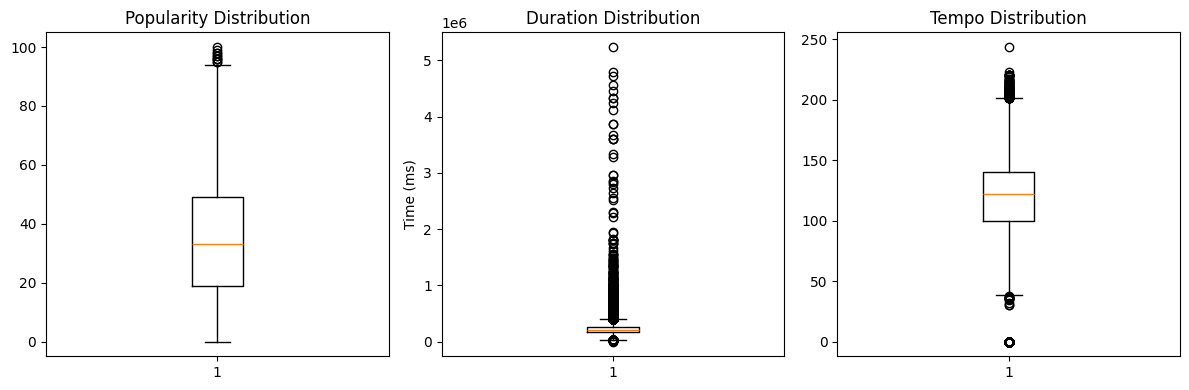

In [ ]:
# ── Visualize outliers (boxplots) ──
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
axes = axes.flatten()

# Popularity
axes[0].boxplot(df['popularity'].dropna(), vert=True)
axes[0].set_title('Popularity Distribution')
axes[0].set_ylabel('Popularity Score')

# Duration
axes[1].boxplot(df['duration_ms'].dropna(), vert=True)
axes[1].set_title('Duration Distribution')
axes[1].set_ylabel('Time (ms)')

# Loudness
axes[2].boxplot(df['loudness'].dropna(), vert=True)
axes[2].set_title('Loudness Distribution')
axes[2].set_ylabel('Decibels (dB)')

# Tempo
axes[3].boxplot(df['tempo'].dropna(), vert=True)
axes[3].set_title('Tempo Distribution')
axes[3].set_ylabel('Beats per Minute (bpm)')

# Energy
axes[4].boxplot(df['energy'].dropna(), vert=True)
axes[4].set_title('Energy Distribution')
axes[4].set_ylabel('Value')

# Danceability
axes[5].boxplot(df['danceability'].dropna(), vert=True)
axes[5].set_title('Danceability Distribution')
axes[5].set_ylabel('Value')

# Valence
axes[6].boxplot(df['valence'].dropna(), vert=True)
axes[6].set_title('Valence Distribution')
axes[6].set_ylabel('Value')

# Speechiness
axes[7].boxplot(df['speechiness'].dropna(), vert=True)
axes[7].set_title('Speechiness Distribution')
axes[7].set_ylabel('Value')

# Acousticness
axes[8].boxplot(df['acousticness'].dropna(), vert=True)
axes[8].set_title('Acousticness Distribution')
axes[8].set_ylabel('Value')

# Instrumentalness
axes[9].boxplot(df['instrumentalness'].dropna(), vert=True)
axes[9].set_title('Instrumentalness Distribution')
axes[9].set_ylabel('Value')

plt.tight_layout()
plt.show()

![Figure 8](images/outlier_box.png)

### ── What do we notice? ──
- `duration`, `loudness`, `speechiness` and `instrumentalness` all have many outliers on the plot, indicating that the data is skewed. This matches the histograms from earlier on in the notebook. 
- `tempo` has outliers on either side of the box. This means that there are some extremely slower songs and faster songs.
- `danceability` has outliers that are lower than the box, meaning there are a few songs that are lower than average.
- `popularity` has outliers that are higher than the box, indicating that most songs have lower popularity scores.
- `valence`, `acousticness`, and `energy`have no outliers.

# IQR Method

In [ ]:
# ── IQR Method for outlier detection ──
def flag_iqr_outliers(series, name=''):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ~series.between(lower, upper)
    print(f"{name}: IQR=[{Q1:.1f}, {Q3:.1f}], bounds=[{lower:.1f}, {upper:.1f}], outliers={outliers.sum()}")
    return outliers, upper

popularity_outliers, pop_upper = flag_iqr_outliers(df['popularity'], 'Popularity')
duration_outliers, dur_upper = flag_iqr_outliers(df['duration_ms'], 'Duration in milliseconds')
loudness_outliers, loud_upper = flag_iqr_outliers(df['loudness'], 'Loudness')
tempo_outliers, tempo_upper = flag_iqr_outliers(df['tempo'], 'Tempo')
energy_outliers, energy_upper = flag_iqr_outliers(df['energy'], 'Energy')
dance_outliers, dance_upper = flag_iqr_outliers(df['danceability'], 'Danceability')
valence_outliers, val_upper = flag_iqr_outliers(df['valence'], 'Valence')
speech_outliers, speech_upper = flag_iqr_outliers(df['speechiness'], 'Speechiness')
acoustic_outliers, acoustic_upper = flag_iqr_outliers(df['acousticness'], 'Acousticness')
inst_outliers, inst_upper = flag_iqr_outliers(df['instrumentalness'], 'Instrumentalness')

In [ ]:
# ── Visualize outliers ──
fig, axes = plt.subplots(5, 2, figsize=(30, 16))
axes = axes.flatten()

# Popularity
sns.histplot(df['popularity'], bins=50, ax=axes[0], color='#60a5fa', alpha=0.7)
axes[0].axvline(pop_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${pop_upper:.2f}')
axes[0].set_title('Total Popularity with Outlier Threshold')
axes[0].legend()

# Duration
sns.histplot(df['duration_ms'], bins=50, ax=axes[1], color='#60a5fa', alpha=0.7)
axes[1].axvline(dur_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${dur_upper:.2f}')
axes[1].set_title('Total Duration with Outlier Threshold')
axes[1].legend()

# Loudness
sns.histplot(df['loudness'], bins=50, ax=axes[2], color='#60a5fa', alpha=0.7)
axes[2].axvline(loud_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${loud_upper:.2f}')
axes[2].set_title('Total Loudness with Outlier Threshold')
axes[2].legend()

# Tempo
sns.histplot(df['tempo'], bins=50, ax=axes[3], color='#60a5fa', alpha=0.7)
axes[3].axvline(tempo_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${tempo_upper:.2f}')
axes[3].set_title('Total Tempo with Outlier Threshold')
axes[3].legend()

# Energy
sns.histplot(df['energy'], bins=50, ax=axes[4], color='#60a5fa', alpha=0.7)
axes[4].axvline(energy_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${energy_upper:.2f}')
axes[4].set_title('Total Energy with Outlier Threshold')
axes[4].legend()

# Danceability
sns.histplot(df['danceability'], bins=50, ax=axes[5], color='#60a5fa', alpha=0.7)
axes[5].axvline(dance_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${dance_upper:.2f}')
axes[5].set_title('Total Danceability with Outlier Threshold')
axes[5].legend()

# Valence
sns.histplot(df['valence'], bins=50, ax=axes[6], color='#60a5fa', alpha=0.7)
axes[6].axvline(val_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${val_upper:.2f}')
axes[6].set_title('Total Valence with Outlier Threshold')
axes[6].legend()

# Speechiness
sns.histplot(df['speechiness'], bins=50, ax=axes[7], color='#60a5fa', alpha=0.7)
axes[7].axvline(speech_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${speech_upper:.2f}')
axes[7].set_title('Total Speechiness with Outlier Threshold')
axes[7].legend()

# Acousticness
sns.histplot(df['acousticness'], bins=50, ax=axes[8], color='#60a5fa', alpha=0.7)
axes[8].axvline(acoustic_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${acoustic_upper:.2f}')
axes[8].set_title('Total Acousticness with Outlier Threshold')
axes[8].legend()

# Instrumentalness
sns.histplot(df['instrumentalness'], bins=50, ax=axes[9], color='#60a5fa', alpha=0.7)
axes[9].axvline(inst_upper, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${inst_upper:.2f}')
axes[9].set_title('Total Instrumentalness with Outlier Threshold')
axes[9].legend()

plt.tight_layout()
plt.show()

![Figure 9](images/outlier_histogram.png)

### ── What do we notice? ──
- Visualizing outliers using the IQR method makes it easier to determine if outliers are the result of an error or just a part of the data. 
- The IQR method shows us that the outliers are not the result of an error. 

## Step 9: Feature Engineering
### Create new features

In [1]:
# ══════════════════════════════════════════════════════════════
#  CREATE NEW FEATURES FROM EXISTING DATA
# ══════════════════════════════════════════════════════════════

# Convert song duration from milliseconds (ms) to minutes (min)
df["duration_min"] = df["duration_ms"] / 60000

df.head()

NameError: name 'df' is not defined

## Step 10: Conclusions
### Summarize findings & recommend next steps

In [ ]:
# ── Final Summary Statistics ──

print("═" * 60)
print("  SPOTIFY — EDA SUMMARY REPORT")
print("═" * 60)
print(f"""
  Dataset Overview
  ───────────────────
  Total Songs:            {df["track_id"].nunique()}
  Total Artists:          {df["artists"].nunique()}
  Total Track Genres:     {df["track_genre"].nunique()}

  Data Quality
  ───────────────────
  Duplicates Removed:     24,259 tracks
  Missing Data Handled:   1 track with missing title, artist, and album (MCAR)
""")
print("═" * 60)


### Initial Conclusions
- There is no correlation between specific audio features and a high popularity score.
- Subgenres that Spotify does not include in this dataset exist.
### Further Hypotheses to explore
- Does explicitness affect popularity and track_genre classification?